In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/apple/Desktop/AI-ML/Datasets/titanic.csv")

In [4]:
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [6]:
df['number'].unique()

<StringArray>
['5', '3', '6', 'A', '2', '1', '4']
Length: 7, dtype: str

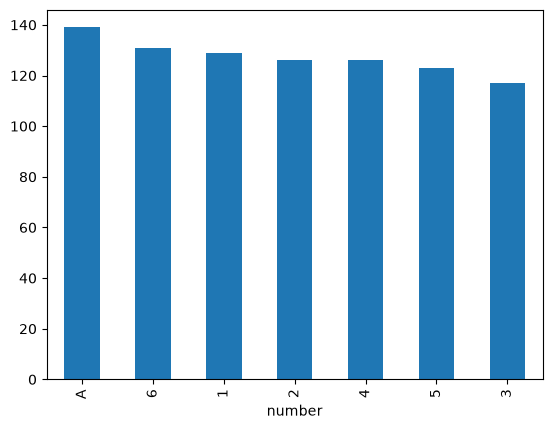

In [9]:
fig = df['number'].value_counts().plot.bar()

In [10]:
# extrac the numerical data
df['number_numerical'] = pd.to_numeric(df['number'], errors='coerce', downcast='integer')

In [12]:
#extract the categorical data
df['number_cateogorical'] = np.where(df['number_numerical'].isnull(), df['number'], np.nan)
# np.where(condition, value_if_true, value_if_false)

df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_cateogorical
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [13]:
df['Cabin'].unique()

<StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [15]:
df['Ticket'].unique()

<StringArray>
[       'A/5 21171',         'PC 17599', 'STON/O2. 3101282',
           '113803',           '373450',           '330877',
            '17463',           '349909',           '347742',
           '237736',
 ...
           '349212',           '349217',           '349257',
             '7552', 'C.A./SOTON 34068',  'SOTON/OQ 392076',
           '211536',           '112053',           '111369',
           '370376']
Length: 681, dtype: str

In [19]:
df['cabin_number'] = df['Cabin'].str.extract(r'(\d+)') ##captures the numerical part
df['cabin_cat'] = df['Cabin'].str[0] #captures the first letter

df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_cateogorical,cabin_number,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


In [26]:
# Extract the last part of Ticket as number
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])

# Convert ticket_num into numerical data
df['ticket_num'] = pd.to_numeric(
    df['ticket_num'],
    errors='coerce',
    downcast='integer'
)

# Extract the first part of Ticket as category
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])

# Remove values that are actually numbers
df['ticket_cat'] = np.where(
    df['ticket_cat'].str.isdigit(),
    np.nan,
    df['ticket_cat']
)

In [28]:
df.head(10)

,Cabin,Ticket,number,Survived,number_numerical,number_cateogorical,cabin_number,cabin_cat,ticker_num,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450,373450.0,NaN
5,NaN,330877,2,0,2.0,NaN,NaN,NaN,330877,330877.0,NaN
6,E46,17463,2,0,2.0,NaN,46,E,17463,17463.0,NaN
7,NaN,349909,5,0,5.0,NaN,NaN,NaN,349909,349909.0,NaN
8,NaN,347742,1,1,1.0,NaN,NaN,NaN,347742,347742.0,NaN
9,NaN,237736,A,1,NaN,A,NaN,NaN,237736,237736.0,NaN
